# Feature-conditioned perturbation encoder — self-contained mini demo (LARRY)

pertTF's default perturbation encoder, **`PertLabelEncoder`**, is an `nn.Embedding`
indexed by genotype. A perturbation **absent from training** therefore only ever has a
*random, untrained* embedding row — so the model structurally cannot make an informed
prediction for an unseen condition (zero-shot / leave-one-condition-out).

**`FeaturePertEncoder`** replaces that lookup with a small trainable MLP on a *fixed
per-perturbation feature matrix*. Because the embedding is a smooth function of
perturbation features, shared across all conditions through one MLP, a condition never
seen in training still gets a meaningful, training-informed embedding.

This notebook is **fully self-contained** — it clones pertTF, installs its
dependencies, downloads a tiny LARRY-derived dataset, then:
1. visualizes the dataset (and where the held-out *test* condition sits),
2. holds out one cytokine condition (`SCF`) entirely from training,
3. runs a mini train/validation loop with both encoders, and
4. shows the zero-shot property directly.

## 0. Setup — make pertTF available & install dependencies

We make the pertTF source importable: if it is already installed or this notebook is run
from inside a pertTF checkout, we use that; otherwise we clone the source (e.g. on a fresh
Colab runtime). Set `CLONE_REF` to pin a specific tag/commit. `torch` is assumed present
(it is on Google Colab and most ML environments).

In [1]:
import os, sys, subprocess, importlib.util, warnings
warnings.filterwarnings("ignore")

# --- make pertTF importable -------------------------------------------------
# Prefer an existing install or a local pertTF checkout (so running this notebook
# from inside the repo uses *that* source); only clone as a last resort, e.g. on a
# fresh Colab runtime. NOTE: the clone tracks the default branch -- pin CLONE_REF to
# a tag/commit if you need a specific pertTF version.
CLONE_REF = None   # e.g. "v0.1.0" or a commit SHA; None => default branch
def _ensure_perttf():
    if importlib.util.find_spec("perttf") is not None:
        return                                          # already installed / on path
    here = os.path.abspath(os.getcwd())
    for d in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        if os.path.isdir(os.path.join(d, "perttf", "model")):
            sys.path.insert(0, d); return               # running inside a checkout
    clone_dir = os.path.abspath("pertTF")
    if not os.path.isdir(clone_dir):
        cmd = ["git", "clone", "--depth", "1"]
        if CLONE_REF:
            cmd += ["--branch", CLONE_REF]
        cmd += ["https://github.com/davidliwei/pertTF.git", clone_dir]
        subprocess.run(cmd, check=True)
    sys.path.insert(0, clone_dir)

_ensure_perttf()

# install the lightweight deps pertTF needs (torch assumed present, e.g. on Colab)
for pkg in ["scanpy", "gdown", "wandb", "omegaconf"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

import numpy as np
import scanpy as sc
import torch

from perttf.model.pertTF import PerturbationTFModel
from perttf.model.config_gen import generate_config
from perttf.model.train_data_gen import produce_training_datasets
from perttf.model.train_function import train, evaluate
from perttf.utils.set_optimizer import create_optimizer_dict

# train_function logs via wandb; silence it so the notebook stays offline / side-effect free
import perttf.model.train_function as _tf
if hasattr(_tf, "wandb"):
    _tf.wandb.log = lambda *a, **k: None

SEED, HELD_OUT, FEAT_DIM, EPOCHS = 0, "SCF", 32, 4
torch.manual_seed(SEED); np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

⚠️ Flash Attention not installed. Model will use standard attention.


device: cuda


## 1. The mini LARRY dataset

LARRY (Weinreb et al. 2020) is an HSPC cytokine lineage-tracing dataset. We map its
columns to the pertTF convention:

| LARRY column | pertTF role |
|---|---|
| `cell_type` | `obs['celltype']` |
| `cytokine_condition` (baseline → `WT`) | `obs['genotype']` (the "perturbation") |

We download a prepared mini dataset directly from Google Drive (1,800 cells × 400 HVGs
across 6 conditions, ~6 MB).

In [2]:
H5AD = "larry_mini.h5ad"
GDRIVE_ID = "1NIzP3rBdFWiqrjpVPydhw1h9fYP5ZeSs"   # shared larry_mini.h5ad on Google Drive
if not os.path.exists(H5AD):
    import gdown
    gdown.download(f"https://drive.google.com/uc?id={GDRIVE_ID}", H5AD, quiet=False)

adata = sc.read_h5ad(H5AD)
adata.obs["genotype"] = adata.obs["genotype"].astype(str)
adata.obs["celltype"] = adata.obs["celltype"].astype(str)
if "X_binned" not in adata.layers:
    adata.layers["X_binned"] = adata.X.copy()
print(adata)
print(chr(10) + "genotype counts:" + chr(10), adata.obs["genotype"].value_counts())

Downloading...
From: https://drive.google.com/uc?id=1NIzP3rBdFWiqrjpVPydhw1h9fYP5ZeSs
To: /tmp/nb_selftest3/larry_mini.h5ad


  0%|          | 0.00/5.93M [00:00<?, ?B/s]

100%|██████████| 5.93M/5.93M [00:00<00:00, 189MB/s]

AnnData object with n_obs × n_vars = 1800 × 400
    obs: 'genotype', 'celltype', 'time_point', 'is_baseline'
    layers: 'X_binned'

genotype counts:
 genotype
full cocktail    300
Epo              300
G-csf            300
SCF              300
M-csf            300
WT               300
Name: count, dtype: int64


### Visualize the dataset

Before training, let's see what the data — and especially the held-out *test* condition —
looks like. We embed the cells with PCA → kNN → UMAP and color by genotype (the cytokine
perturbation), cell type, and the train/held-out split. `SCF` (red) is the condition we
remove from training and must predict zero-shot.

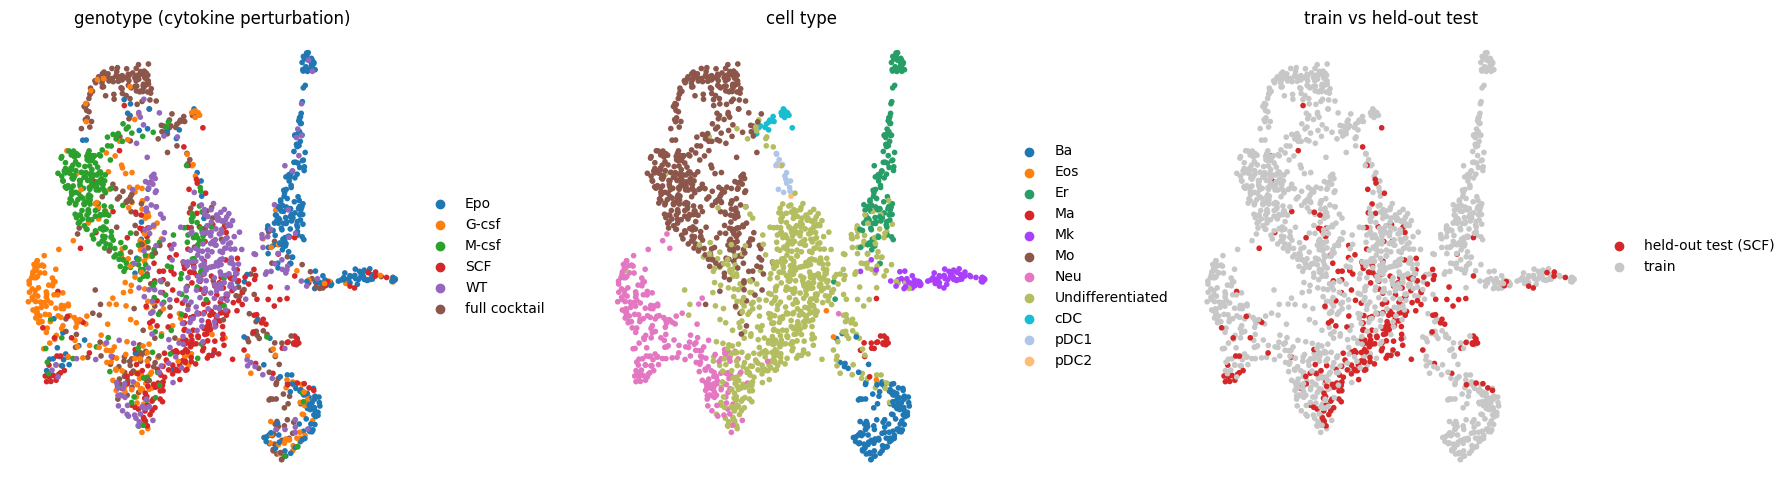

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

def visualize_dataset(adata, held_out=HELD_OUT, show=True, save_path=None):
    av = adata.copy()
    av.X = av.layers["X_binned"]                         # log-normalized expression
    sc.pp.pca(av, n_comps=30, random_state=SEED)
    sc.pp.neighbors(av, n_neighbors=15, random_state=SEED)
    sc.tl.umap(av, random_state=SEED)
    av.obs["split"] = np.where(av.obs["genotype"].values == held_out,
                               "held-out test (" + held_out + ")", "train")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sc.pl.umap(av, color="genotype", ax=axes[0], show=False,
               title="genotype (cytokine perturbation)", frameon=False)
    sc.pl.umap(av, color="celltype", ax=axes[1], show=False, title="cell type", frameon=False)
    sc.pl.umap(av, color="split", ax=axes[2], show=False, title="train vs held-out test",
               frameon=False,
               palette={"held-out test (" + held_out + ")": "#d62728", "train": "#c7c7c7"})
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=120, bbox_inches="tight")
    if show:
        plt.show()
    return av

_ = visualize_dataset(adata)

## 2. Label maps and the perturbation feature matrix

We build a **union** `genotype_to_index` over *all* conditions — including the held-out
one — so `SCF` gets an index (and a feature row) even though it contributes no training
cells. `pert_features` has shape `(n_genotypes, feat_dim)`, where **row `i` is the
feature vector for the genotype whose index is `i`**.

Feature provenance matters for an honest zero-shot test:
- **Trained conditions** — features summarize their molecular signature, computed from the
  **training** cells only.
- **Held-out condition** — it has no training cells, so its row must come from *external
  prior knowledge* that exists for unseen perturbations (gene/drug identity embeddings,
  receptor/target genes, chemical structure). This self-contained demo has no such external
  table, so we **stand in** for it with the condition's own pseudobulk signature — a *proxy*
  for prior knowledge, never used as a training label. Swap `heldout_feature_row` for a real
  external descriptor in practice.

In [4]:
genotype_to_index = {g: i for i, g in enumerate(sorted(adata.obs["genotype"].unique()))}
cell_type_to_index = {c: i for i, c in enumerate(sorted(adata.obs["celltype"].unique()))}
held_idx = genotype_to_index[HELD_OUT]

# split off the held-out condition up front so its cells never enter training
train_adata = adata[adata.obs["genotype"] != HELD_OUT].copy()
heldout_adata = adata[adata.obs["genotype"] == HELD_OUT].copy()

def pseudobulk(av):
    X = av.layers["X_binned"]
    return (X.toarray() if hasattr(X, "toarray") else np.asarray(X)).mean(axis=0)

def build_pert_features(genotype_to_index, train_adata, heldout_row, feat_dim=FEAT_DIM):
    pb = np.zeros((len(genotype_to_index), train_adata.shape[1]), dtype=np.float32)
    for g, i in genotype_to_index.items():
        if g == HELD_OUT:
            pb[i] = heldout_row                                   # external prior-knowledge proxy
        else:                                                     # trained conditions: TRAIN cells only
            pb[i] = pseudobulk(train_adata[train_adata.obs["genotype"].values == g])
    mu, sd = pb.mean(0, keepdims=True), pb.std(0, keepdims=True) + 1e-8
    U, S, Vt = np.linalg.svd((pb - mu) / sd, full_matrices=False)  # PCA via SVD (n_g is tiny)
    feats = (U * S)[:, :feat_dim]
    if feats.shape[1] < feat_dim:
        feats = np.pad(feats, ((0, 0), (0, feat_dim - feats.shape[1])))
    return feats.astype(np.float32)

# stand-in for an EXTERNAL feature row for the unseen condition (see markdown above)
heldout_feature_row = pseudobulk(heldout_adata)
pert_features = build_pert_features(genotype_to_index, train_adata, heldout_feature_row)
print("genotype_to_index:", genotype_to_index)
print("pert_features:", pert_features.shape, "| held-out row index:", held_idx)

genotype_to_index: {'Epo': 0, 'G-csf': 1, 'M-csf': 2, 'SCF': 3, 'WT': 4, 'full cocktail': 5}
pert_features: (6, 32) | held-out row index: 3


## 3. Hold out a condition and build the training datasets

We train on every condition **except** `SCF`. The genotype index space still includes
`SCF`, so the model allocates an encoder slot for it — but it never sees an `SCF` cell.

`make_config()` sets `perturbation_input=True`: the perturbation embedding is injected
into the transformer, so the masked-expression reconstruction loss flows back through the
perturbation encoder (otherwise the encoder would get no gradient at all).

In [5]:
def make_config():
    hp = dict(
        seed=SEED,
        dataset_name="larry_mini_feature_pert_demo",
        do_train=True,
        GEPC=False,
        ecs_thres=0.0, ecs_weight=1.0,
        dab_weight=0.0,
        this_weight=1.0, next_weight=0.0,
        next_cell_pred_type="identity",            # no next-cell head -> simplest setup
        cell_type_classifier=True, cell_type_classifier_weight=1.0,
        # perturbation injected as input so the reconstruction loss trains the encoder;
        # genotype classifier zeroed because predicting a given-as-input label is leaky.
        genotype_classifier=False, perturbation_classifier_weight=0.0,
        ps_weight=0.0,
        perturbation_input=True,
        CCE=False,
        mask_ratio=0.15,
        epochs=EPOCHS,
        n_bins=0,                                  # expression already log-normalized
        lr=1e-3, batch_size=64,
        layer_size=32, nlayers=2, nhead=2, dropout=0.2,
        schedule_ratio=0.97, schedule_interval=1, log_interval=50,
        fast_transformer=False, pre_norm=False, amp=False,
        do_sample_in_train=False,
        ADV=False, adv_weight=0, adv_E_delay_epochs=0, adv_D_delay_epochs=0, lr_ADV=1e-3,
        DSBN=False, per_seq_batch_sample=False, use_batch_label=False,
        explicit_zero_prob=False,
        n_hvg=400,                                 # = n_genes (simple sampling keeps all)
        mask_value=-1, pad_value=-2,
        pad_token="<pad>", cls_token="<cls>",
        sampling_mode="simple", non_hvg_size=0,
        fix_nonzero_prop=True, nonzero_prop=0.0,
        hvg_col="highly_variable",
        mvc_masked_train=False,
        distribution=None, use_ot=False,
    )
    config, _ = generate_config(hp, wandb_mode="disabled")
    return config

print("training cells:", train_adata.n_obs, "(held out all",
      heldout_adata.n_obs, "'" + HELD_OUT + "' cells)")

config = make_config()
data_gen = produce_training_datasets(
    train_adata, config,
    next_cell_pred=config.next_cell_pred_type,
    genotype_to_index=genotype_to_index,
    cell_type_to_index=cell_type_to_index,
)
print("n_perturb =", data_gen["n_perturb"], "(index space includes the unseen condition)")

wandb: WARNING `start_method` is deprecated and will be removed in a future version of wandb. This setting is currently non-functional and safely ignored.


training cells: 1500 (held out all 300 'SCF' cells)
{'seed': 0, 'dataset_name': 'larry_mini_feature_pert_demo', 'do_train': True, 'GEPC': False, 'ecs_thres': 0.0, 'ecs_weight': 1.0, 'dab_weight': 0.0, 'this_weight': 1.0, 'next_weight': 0, 'next_cell_pred_type': 'identity', 'cell_type_classifier': True, 'cell_type_classifier_weight': 1.0, 'genotype_classifier': False, 'perturbation_classifier_weight': 0.0, 'ps_weight': 0.0, 'perturbation_input': True, 'CCE': False, 'mask_ratio': 0.15, 'epochs': 4, 'n_bins': 0, 'lr': 0.001, 'batch_size': 64, 'layer_size': 32, 'nlayers': 2, 'nhead': 2, 'dropout': 0.2, 'schedule_ratio': 0.97, 'schedule_interval': 1, 'log_interval': 50, 'fast_transformer': False, 'pre_norm': False, 'amp': False, 'do_sample_in_train': False, 'ADV': False, 'adv_weight': 0, 'adv_E_delay_epochs': 0, 'adv_D_delay_epochs': 0, 'lr_ADV': 0.001, 'DSBN': False, 'per_seq_batch_sample': False, 'use_batch_label': False, 'explicit_zero_prob': False, 'n_hvg': 400, 'mask_value': -1, 'pad_v

## 4. Model + training helpers

`build_model` passes `pert_features=...` to `PerturbationTFModel` — that single argument
is the only switch that selects `FeaturePertEncoder` instead of `PertLabelEncoder`.

In [6]:
def build_model(data_gen, config, pert_features=None):
    vocab = data_gen["vocab"]
    return PerturbationTFModel(
        data_gen["n_perturb"],                 # n_perturb (= len(genotype_to_index))
        3,                                     # nlayers_pert
        len(data_gen["ps_names"]),             # n_ps
        len(vocab),                            # ntokens
        config.layer_size,                     # embsize
        config.nhead,
        config.layer_size,                     # d_hid
        config.nlayers,
        vocab=vocab,
        dropout=config.dropout,
        pad_token=config.pad_token,
        pad_value=config.pad_value,
        do_mvc=config.GEPC,
        do_dab=False,
        use_batch_labels=config.use_batch_label,
        num_batch_labels=data_gen["num_batch_types"],
        domain_spec_batchnorm=config.DSBN,
        n_input_bins=config.n_bins,
        ecs_threshold=config.ecs_thres,
        explicit_zero_prob=config.explicit_zero_prob,
        use_fast_transformer=config.fast_transformer,
        pre_norm=config.pre_norm,
        n_cls=data_gen["n_cls"],
        nlayers_cls=3,
        pert_features=pert_features,           # <-- features => FeaturePertEncoder
    )

@torch.no_grad()
def pert_embeddings(model, device):
    # embedding the encoder assigns to each genotype index: (n_genotypes, embed_dim)
    idx = torch.arange(model.n_pert, device=device)
    return model.pert_encoder(idx).detach().cpu().numpy()

def train_model(model, data_gen, config, device, tag):
    model.to(device)
    optim_dict = create_optimizer_dict(model, device, config, data_gen["num_batch_types"])
    print("\n=== training [" + tag + "] (" + type(model.pert_encoder).__name__ + ") ===")
    for epoch in range(1, config.epochs + 1):
        train(model, data_gen["train_loader"], config, data_gen["vocab"],
              optim_dict, epoch=epoch, device=device)
        m = evaluate(model, data_gen["valid_loader"], config,
                     data_gen["vocab"], epoch=epoch, device=device)
        print("  epoch %d/%d | val mse %6.4f | val celltype-CE %6.4f | val genotype-CE %6.4f"
              % (epoch, config.epochs, m[0], m[7], m[8]))
    return model

## 5. Train with `FeaturePertEncoder`

We record the encoder's output for the held-out condition *before* and *after* training.

In [7]:
torch.manual_seed(SEED)
model_feat = build_model(data_gen, config, pert_features=pert_features)
print("encoder:", type(model_feat.pert_encoder).__name__)

emb_feat_before = pert_embeddings(model_feat, torch.device("cpu"))
model_feat = train_model(model_feat, data_gen, config, device, "FeaturePertEncoder")
emb_feat_after = pert_embeddings(model_feat, device)

encoder: FeaturePertEncoder



=== training [FeaturePertEncoder] (FeaturePertEncoder) ===


  epoch 1/4 | val mse 0.1458 | val celltype-CE 1.6008 | val genotype-CE 0.0000


  epoch 2/4 | val mse 0.1509 | val celltype-CE 1.4730 | val genotype-CE 0.0000


  epoch 3/4 | val mse 0.1431 | val celltype-CE 1.4149 | val genotype-CE 0.0000


  epoch 4/4 | val mse 0.1347 | val celltype-CE 1.3413 | val genotype-CE 0.0000


## 6. Baseline: the default `PertLabelEncoder`

Same data, same loop, but `pert_features=None`. Its only learnable state for a condition
is one `nn.Embedding` row; we snapshot the held-out row before/after training.

In [8]:
torch.manual_seed(SEED)
model_lbl = build_model(data_gen, config, pert_features=None)
print("encoder:", type(model_lbl.pert_encoder).__name__)

raw_lbl_before = model_lbl.pert_encoder.embedding.weight[held_idx].detach().cpu().numpy().copy()
model_lbl = train_model(model_lbl, data_gen, config, device, "PertLabelEncoder")
raw_lbl_after = model_lbl.pert_encoder.embedding.weight[held_idx].detach().cpu().numpy().copy()

encoder: PertLabelEncoder

=== training [PertLabelEncoder] (PertLabelEncoder) ===


  epoch 1/4 | val mse 0.1471 | val celltype-CE 1.6167 | val genotype-CE 0.0000


  epoch 2/4 | val mse 0.1508 | val celltype-CE 1.4910 | val genotype-CE 0.0000


  epoch 3/4 | val mse 0.1504 | val celltype-CE 1.4395 | val genotype-CE 0.0000


  epoch 4/4 | val mse 0.1453 | val celltype-CE 1.4150 | val genotype-CE 0.0000


## 7. Zero-shot check

Did training teach the model anything about a condition with **zero training cells**?

In [9]:
def l2(a, b):
    return float(np.linalg.norm(a - b))

print("Unseen condition '" + HELD_OUT + "' (index " + str(held_idx) + ")\n")
print("PertLabelEncoder  — only state = one nn.Embedding row")
print("   ||row_after - row_before||  = %.6f   (no gradient -> frozen at init)\n"
      % l2(raw_lbl_after, raw_lbl_before))
print("FeaturePertEncoder — embedding = sharedMLP(features), no per-condition row")
print("   ||emb_after - emb_before||  = %.6f   (informed by training on other conditions)"
      % l2(emb_feat_after[held_idx], emb_feat_before[held_idx]))

Unseen condition 'SCF' (index 3)

PertLabelEncoder  — only state = one nn.Embedding row
   ||row_after - row_before||  = 0.000000   (no gradient -> frozen at init)

FeaturePertEncoder — embedding = sharedMLP(features), no per-condition row
   ||emb_after - emb_before||  = 0.912440   (informed by training on other conditions)


**Takeaway.** The `PertLabelEncoder` row for the unseen condition is *exactly* unchanged
(`0.000000`) — it receives no gradient, so the model is no better than random init for
that condition. The `FeaturePertEncoder` embedding for the same unseen condition moves
substantially, because the shared MLP is trained on the other conditions and the unseen
condition's embedding is a smooth function of its features.

### Using it in your own code

```python
from perttf.model.pertTF import PerturbationTFModel        # or HFPerturbationTFModel
# pert_features: (n_pert, feat_dim), row i = features for genotype index i.
# Assign held-out / novel conditions an index + feature row in genotype_to_index.
model = PerturbationTFModel(..., pert_features=pert_features)
```

For the HuggingFace path, `pert_features` is forwarded by `HFPerturbationTFModel.__init__`,
saved by `save_pretrained` (in `running_parameters.pt`), and restored by `from_pretrained`,
so the feature encoder survives a full save/load round-trip.